In [287]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [288]:
class Value:
    def __init__(self, data, _children=(), _op='', _label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self._label = _label

    def __repr__(self):
        return f"Value(data = {self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1) / (math.exp(2*n) + 1)
        out = Value(t, (self, ), "tanh")

        def _backward():
            self.grad = (1 - t**2) * out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

In [289]:
a = Value(3, _label='a')
b = Value(-2, _label='b')
c = Value(5, _label='c')

In [290]:
a * b

Value(data = -6)

In [291]:
a + b

Value(data = 1)

In [292]:
d = a * b; d._label = 'd'
e = d + c; e._label = 'e'
f = Value(-1, _label='f')
L = e * f; L._label = 'L'
L

Value(data = 1)

In [293]:
e._prev

{Value(data = -6), Value(data = 5)}

In [294]:
e._op

'+'

In [295]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n._label, n.data, n.grad, ), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

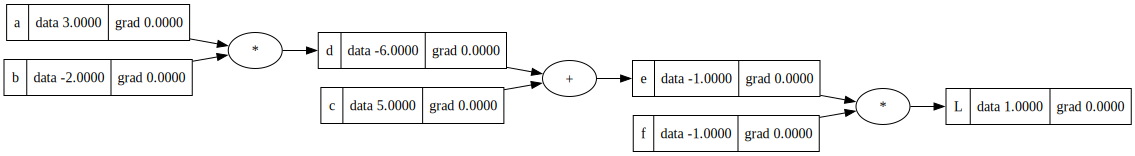

In [296]:
draw_dot(L)

In [297]:
# data
x1 = Value(2.0, _label="x1")
x2 = Value(0.0, _label="x2")

# weights
w1 = Value(-3.0, _label="w1")
w2 = Value(1.0, _label="w2")

#bias
b = Value(6.8813735, _label="b")

x1w1 = x1 * w1; x1w1._label = "x1w1"
x2w2 = x2 * w2; x2w2._label = "x2w2"
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2._label = "x1w1x2w2"
n = x1w1x2w2 + b; n._label = "n"
o = n.tanh(); o._label = "o"

In [298]:
o.backward()

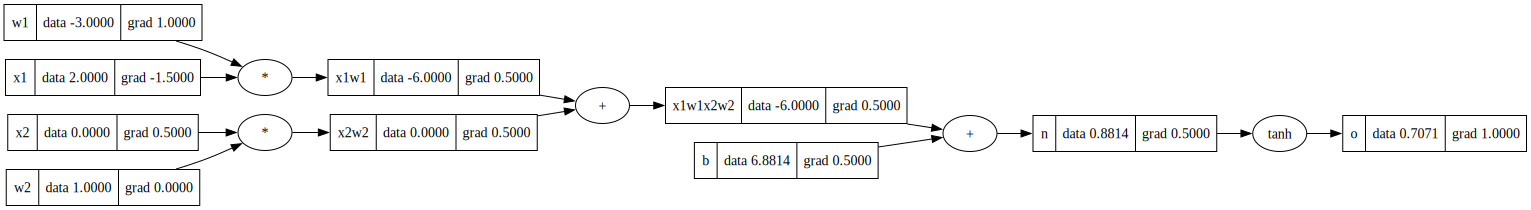

In [299]:
draw_dot(o)